In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# 'RELIANCE.NS' targets Reliance on the National Stock Exchange of India
ticker = "RELIANCE.NS"

print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start="2021-05-18", end="2026-05-18")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print("\n--- First 5 Rows of Data ---")
print(data.head())
print(data.tail())

print("---Info---")
print(data.info())

[*********************100%***********************]  1 of 1 completed


--- First 5 Rows of Data ---
Price            Close        High         Low        Open    Volume
Date                                                                
2021-05-18  901.398682  908.041463  894.393153  898.247360  12064918
2021-05-19  905.524841  914.321435  894.166413  897.793820  16317002
2021-05-20  900.242371  911.804871  898.247293  905.910251  11422532
2021-05-21  908.018799  911.215456  900.514516  903.235087  10785605
2021-05-24  900.355774  911.306181  898.700776  910.489956   8551760
Price             Close         High          Low         Open    Volume
Date                                                                    
2026-05-11  1388.199951  1428.000000  1382.000000  1420.000000  15261787
2026-05-12  1364.000000  1393.500000  1360.300049  1392.000000  24357500
2026-05-13  1358.800049  1372.400024  1352.400024  1361.400024  13797989
2026-05-14  1361.800049  1378.000000  1358.400024  1365.199951  17303059
2026-05-15  1336.400024  1364.800049  1329.199951

In [2]:
# 1. Use .squeeze() for removig the unnecessary dimensional vectors
adj_close = data['Close'].squeeze()

print("-----------Summary Statistics---------")
print(adj_close.describe())

# 2 Check for missing data
print(data.isnull().sum())

# 3. Calculate variance (this will now be a single number scalar!)
variance = adj_close.var()
print(f"\nAsset Variance: {variance:.2f}")

-----------Summary Statistics---------
count    1237.000000
mean     1257.147687
std       162.437180
min       890.153564
25%      1132.248535
50%      1228.714478
75%      1408.800049
max      1592.300049
Name: Close, dtype: float64
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Asset Variance: 26385.84


In [3]:
# Find the exact dates of the highest and lowest prices
highest_price_date = adj_close.idxmax()
lowest_price_date = adj_close.idxmin()

# Find the exact prices on those dates
highest_price = adj_close.max()
lowest_price = adj_close.min()

print(f"5-Year High: INR {highest_price:.2f} on {highest_price_date.strftime('%Y-%m-%d')}")
print(f"5-Year Low:  INR {lowest_price:.2f} on {lowest_price_date.strftime('%Y-%m-%d')}")

mean_val = adj_close.mean()
median_val = adj_close.median()

print(f"\nMean Price: INR {mean_val:.2f}")
print(f"Median Price: INR {median_val:.2f}")

if mean_val > median_val:
    print("Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.")
else:
    print("Insight: The data is negatively skewed or symmetric.")

5-Year High: INR 1592.30 on 2026-01-02
5-Year Low:  INR 890.15 on 2021-05-25

Mean Price: INR 1257.15
Median Price: INR 1228.71
Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.


In [4]:
# 1. Calculate percentage change row-by-row on our squeezed Close prices
daily_returns = adj_close.pct_change()

print("--- Raw Daily Returns Table ---")
print(daily_returns.head())

# 2. THE PITFALL: Look at the very first row. It will say 'NaN' 
# Why? Because the first day has no "yesterday" to calculate a change from!
# We must clean this using .dropna() or our future math will break.

clean_returns = daily_returns.dropna()

print("\n--- Cleaned Summary Statistics for Returns ---")
print(clean_returns.describe())

# 3. Scale up the metrics to make them human-readable
print(f"\nMaximum Single-Day Gain: {clean_returns.max() * 100:.2f}%")
print(f"Maximum Single-Day Loss: {clean_returns.min() * 100:.2f}%")

--- Raw Daily Returns Table ---
Date
2021-05-18         NaN
2021-05-19    0.004578
2021-05-20   -0.005834
2021-05-21    0.008638
2021-05-24   -0.008439
Name: Close, dtype: float64

--- Cleaned Summary Statistics for Returns ---
count    1236.000000
mean        0.000419
std         0.014173
min        -0.074851
25%        -0.007983
50%         0.000571
75%         0.007882
max         0.070192
Name: Close, dtype: float64

Maximum Single-Day Gain: 7.02%
Maximum Single-Day Loss: -7.49%


In [5]:
daily_volatility = clean_returns.std()
print(f"Standard deviation of eveeryday return: {daily_volatility * 100:.2f}%")

Standard deviation of eveeryday return: 1.42%


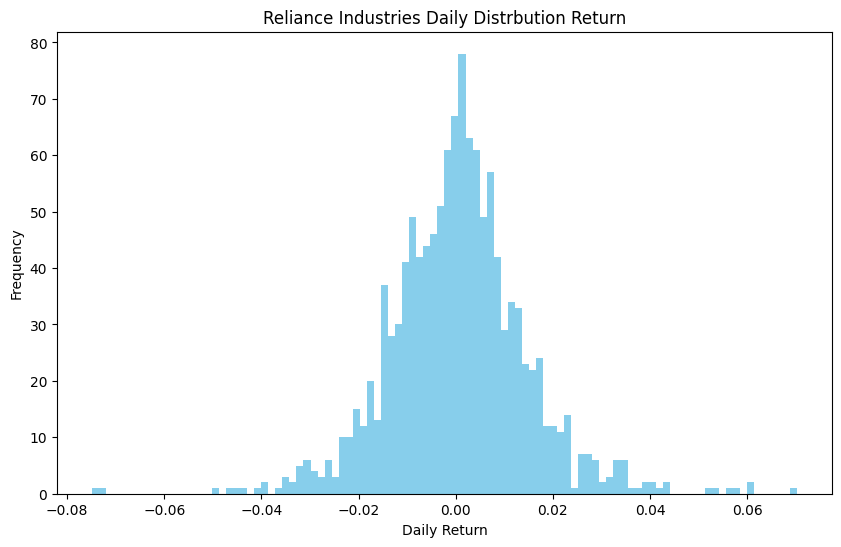

avr = 22.49


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(clean_returns, bins=100 , color = 'skyblue')
plt.title("Reliance Industries Daily Distrbution Return")
plt.ylabel("Frequency")
plt.xlabel("Daily Return")
plt.show()

annualized_volatility_rate = daily_volatility*15.87
print(f"avr = {annualized_volatility_rate * 100:.2f}")

In [7]:
log_returns = np.log(adj_close) - np.log(adj_close.shift(1))
clean_log_returns = log_returns.dropna()

slice_start, slice_end = 5,10;

summed_log_return = clean_log_returns.iloc[slice_start:slice_end].sum()

price_start = adj_close.iloc[slice_start]
price_end = adj_close.iloc[slice_end]
direct_log_return = np.log(price_end / price_start)

skew = clean_log_returns.skew()
kurtosis = clean_log_returns.kurtosis()

print(f"Summed Daily Log Returns: {summed_log_return:.6f}")
print(f"Direct Period Log Return: {direct_log_return:.6f}")

print(f"Log Return Skewness     : {skew:.4f}")
print(f"Excess Kurtosis (Tails) : {kurtosis:.4f}")

if kurtosis > 0:
    print("Insight: The asset exhibits Leptokurtosis (Fat Tails).")
    print("Standard risk models will structurally underestimate the chance of a market crash.")

Summed Daily Log Returns: 0.099670
Direct Period Log Return: 0.099670
Log Return Skewness     : 0.0284
Excess Kurtosis (Tails) : 2.8244
Insight: The asset exhibits Leptokurtosis (Fat Tails).
Standard risk models will structurally underestimate the chance of a market crash.


In [8]:
# STEP 1: Calculate a 20-Day Rolling Mean (Simple Moving Average)
# TODO: Use .rolling() with a window of 20 and apply the mean function to adj_close.
# Save it into a new column inside your dataframe called data['SMA_20']
data['SMA_10'] = adj_close.rolling(window = 20).mean()


# STEP 2: Calculate a 20-Day Rolling Volatility (Standard Deviation)
# TODO: Use .rolling() with a window of 20 and apply the standard deviation (.std()) function.
# Save it into a new column called data['Rolling_Vol_20']
data['Rolling_Vol_10'] = adj_close.rolling(window=20).std()


print("--- 20-Day Rolling Window Framework ---")
# This prints out a slice where the rolling windows have enough data to compute
print(data[['Close', 'SMA_10', 'Rolling_Vol_10']].dropna().head(10))


# STEP 3: Fetch the latest data point for our trading signal
# We use .iloc[-1] to grab the very last row (today's live market data)
latest_row = data.iloc[-1]
current_price = latest_row['Close'].squeeze()
current_sma = latest_row['SMA_10'].squeeze()


print("\n=========================================")
print("       📡 ALGORITHMIC TREND SIGNAL       ")
print("=========================================")
print(f"Current Closing Price : INR {current_price:.2f}")
print(f"20-Day Moving Average : INR {current_sma:.2f}")
print("-----------------------------------------")


# STEP 4: Write the Conditional Trading Logic
# TODO: Write an if/else block:
# - IF current_price is greater than current_sma: Print a BULLISH momentum message.
# - ELSE: Print a BEARISH momentum message.
# WRITE YOUR CODE HERE

if(current_price>current_sma):
    print("Signal: Bullish Momentum-> The current price is higher than the average of the previous trend:")
else:
    print("Signal: Bearish Momentum-> The current price is lower than the average of the previous trend ")


print("=========================================")

--- 20-Day Rolling Window Framework ---
Price             Close      SMA_10  Rolling_Vol_10
Date                                               
2021-06-14  1021.456604  955.989346       49.574963
2021-06-15  1023.777100  962.108267       50.032661
2021-06-16  1006.304565  967.147253       49.100261
2021-06-17  1008.147339  972.542502       47.255435
2021-06-18  1012.697571  977.776440       45.497071
2021-06-21  1017.975586  983.657431       42.463593
2021-06-22  1012.743042  989.786905       36.714810
2021-06-23  1003.460754  995.295831       28.908589
2021-06-24   979.868469  999.487976       17.637224
2021-06-25   957.549988  999.873083       16.546660

       📡 ALGORITHMIC TREND SIGNAL       
Current Closing Price : INR 1336.40
20-Day Moving Average : INR 1391.84
-----------------------------------------
Signal: Bearish Momentum-> The current price is lower than the average of the previous trend 


In [9]:
df = data.copy().sort_index()
df['Signal'] = np.where(df['Close'] > df['SMA_10'], 1, -1)
df['Position'] = df['Signal'].shift(1)
df = df.dropna()
df.head()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Signal,Position
Date,,,,,,,,,
2021-06-14,1021.456604,1027.531003,998.774221,1007.851760,20332436,955.989346,49.574963,1,-1.0
2021-06-15,1023.777100,1035.106887,1019.363469,1028.782271,15174215,962.108267,50.032661,1,1.0
2021-06-16,1006.304565,1022.434741,1003.688245,1021.456502,10797349,967.147253,49.100261,1,1.0
2021-06-17,1008.147339,1016.951853,991.880682,1001.026400,15745975,972.542502,47.255435,1,1.0
2021-06-18,1012.697571,1016.951973,993.905579,1012.629330,29369026,977.776440,45.497071,1,1.0


In [10]:
df['Market_Return'] = df['Close'].pct_change()
df['Strategy_Return'] = df['Market_Return'] * df['Position']

df['Baseline_Equity'] = (1 + df['Market_Return'].fillna(0)).cumprod()
df['Strategy_Equity'] = (1 + df['Strategy_Return'].fillna(0)).cumprod()
df.tail()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Signal,Position,Market_Return,Strategy_Return,Baseline_Equity,Strategy_Equity
Date,,,,,,,,,,,,,
2026-05-11,1388.199951,1428.000000,1382.000000,1420.000000,15261787,1389.165009,46.899853,-1,1.0,-0.032748,-0.032748,1.359040,0.803532
2026-05-12,1364.000000,1393.500000,1360.300049,1392.000000,24357500,1391.610010,44.021774,-1,-1.0,-0.017433,0.017433,1.335348,0.817540
2026-05-13,1358.800049,1372.400024,1352.400024,1361.400024,13797989,1392.345013,43.303641,-1,-1.0,-0.003812,0.003812,1.330257,0.820657
2026-05-14,1361.800049,1378.000000,1358.400024,1365.199951,17303059,1393.270013,42.388786,-1,-1.0,0.002208,-0.002208,1.333194,0.818845
2026-05-15,1336.400024,1364.800049,1329.199951,1356.800049,19976192,1391.840015,43.849911,-1,-1.0,-0.018652,0.018652,1.308328,0.834118


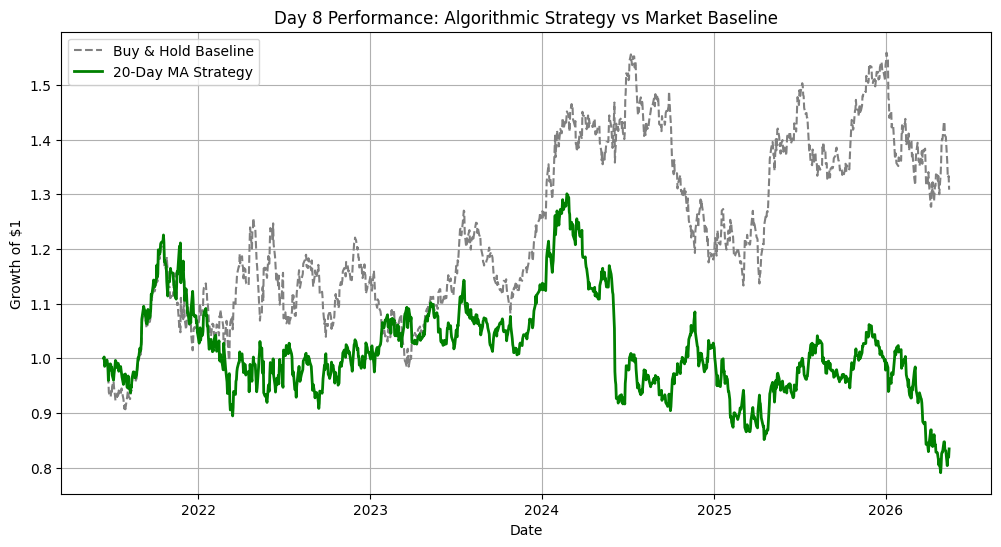

In [11]:
#MA Strategy
plt.figure(figsize=(12, 6))

plt.plot(df['Baseline_Equity'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df['Strategy_Equity'], label='20-Day MA Strategy', color='green', linewidth=2)

plt.title('Day 8 Performance: Algorithmic Strategy vs Market Baseline')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# This will show if our strategy is actually generating trades
print(df['Position'].value_counts())

Position
 1.0    651
-1.0    567
Name: count, dtype: int64


In [13]:
# Create a list to store our results
performance_results = []

for w in range(5, 101, 5):
    temp_df = data.copy().sort_index()
    
    temp_df['MA'] = temp_df['Close'].rolling(window=w).mean()
    temp_df['Signal'] = np.where(temp_df['Close'] > temp_df['MA'], 1, -1)
    temp_df['Position'] = temp_df['Signal'].shift(1)
    temp_df = temp_df.dropna()
    
    # Calculate returns
    temp_df['Market_Return'] = temp_df['Close'].pct_change()
    temp_df['Strategy_Return'] = temp_df['Market_Return'] * temp_df['Position']
    
    # Calculate total cumulative return 
    total_return = (1 + temp_df['Strategy_Return'].fillna(0)).prod() - 1
    performance_results.append({'Window_Size': w, 'Total_Return': total_return})

results_df = pd.DataFrame(performance_results)
best_windows = results_df.sort_values(by='Total_Return', ascending=False)

print("--- TOP 5 MOST PROFITABLE WINDOWS ---")
print(best_windows.head())
print("\n--- TOP 5 WORST PERFORMING WINDOWS ---")
print(best_windows.tail())

--- TOP 5 MOST PROFITABLE WINDOWS ---
    Window_Size  Total_Return
6            35      0.192784
5            30      0.124336
9            50      0.056115
1            10      0.008519
10           55     -0.048853

--- TOP 5 WORST PERFORMING WINDOWS ---
    Window_Size  Total_Return
15           80     -0.565643
18           95     -0.604009
19          100     -0.604570
17           90     -0.635428
16           85     -0.646886


In [14]:
#windows 20 is the fast moving average and 50 is the slow moving acerage
df_dual = data.copy().sort_index()

df_dual['Fast_MA'] = df_dual['Close'].rolling(window = 20).mean()
df_dual['Slow_MA'] = df_dual['Close'].rolling(window = 50).mean()

df_dual['Signal'] = np.where(df_dual['Fast_MA'] > df_dual['Slow_MA'],1 ,-1)
df_dual['Position'] = df_dual['Signal'].shift(1)

df_dual = df_dual.dropna()

In [15]:
df_dual['Market_Return'] = df_dual['Close'].pct_change()
df_dual['Strategy_Return'] = df_dual['Market_Return'] * df_dual['Position']

df_dual['Baseline_Equity'] = (1 + df_dual['Market_Return'].fillna(0)).cumprod()
df_dual['Strategy_Equity'] = (1 + df_dual['Strategy_Return'].fillna(0)).cumprod()

df_dual.tail()

Price,Close,High,Low,Open,Volume,SMA_10,Rolling_Vol_10,Fast_MA,Slow_MA,Signal,Position,Market_Return,Strategy_Return,Baseline_Equity,Strategy_Equity
Date,,,,,,,,,,,,,,,
2026-05-11,1388.199951,1428.000000,1382.000000,1420.000000,15261787,1389.165009,46.899853,1389.165009,1383.722004,1,1.0,-0.032748,-0.032748,1.484627,0.799527
2026-05-12,1364.000000,1393.500000,1360.300049,1392.000000,24357500,1391.610010,44.021774,1391.610010,1382.426003,1,1.0,-0.017433,-0.017433,1.458746,0.785590
2026-05-13,1358.800049,1372.400024,1352.400024,1361.400024,13797989,1392.345013,43.303641,1392.345013,1381.632004,1,1.0,-0.003812,-0.003812,1.453185,0.782595
2026-05-14,1361.800049,1378.000000,1358.400024,1365.199951,17303059,1393.270013,42.388786,1393.270013,1380.732004,1,1.0,0.002208,0.002208,1.456393,0.784323
2026-05-15,1336.400024,1364.800049,1329.199951,1356.800049,19976192,1391.840015,43.849911,1391.840015,1379.582004,1,1.0,-0.018652,-0.018652,1.429229,0.769694


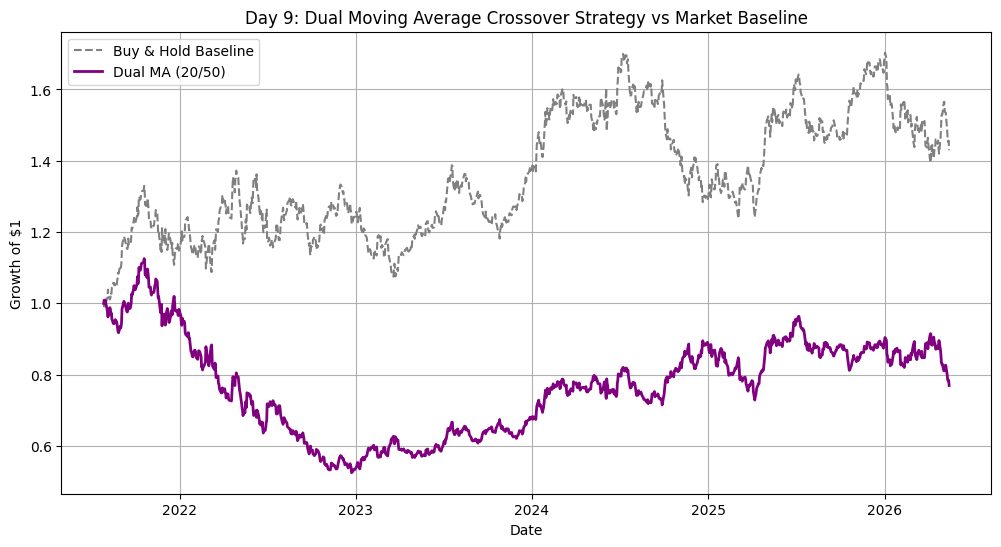

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df_dual['Baseline_Equity'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_dual['Strategy_Equity'], label=f'Dual MA ({20}/{50})', color='purple', linewidth=2)

plt.title(f'Day 9: Dual Moving Average Crossover Strategy vs Market Baseline')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
 print(f"Start Date: {df_dual.index.min().date()} | End Date: {df_dual.index.max().date()} | Total Trading Days: {len(df_dual)}")

Start Date: 2021-07-27 | End Date: 2026-05-15 | Total Trading Days: 1188


In [18]:
# Time for ADX
df_diag = data.copy()
df_diag['SMA_100'] = df_diag['Close'].rolling(window=100).mean()
df_diag['Dev'] = (df_diag['Close'] - df_diag['SMA_100']).abs() / df_diag['SMA_100']

print(f"Average Deviation from Long-Term Mean: {df_diag['Dev'].mean() * 100:.2f}%")

Average Deviation from Long-Term Mean: 5.61%


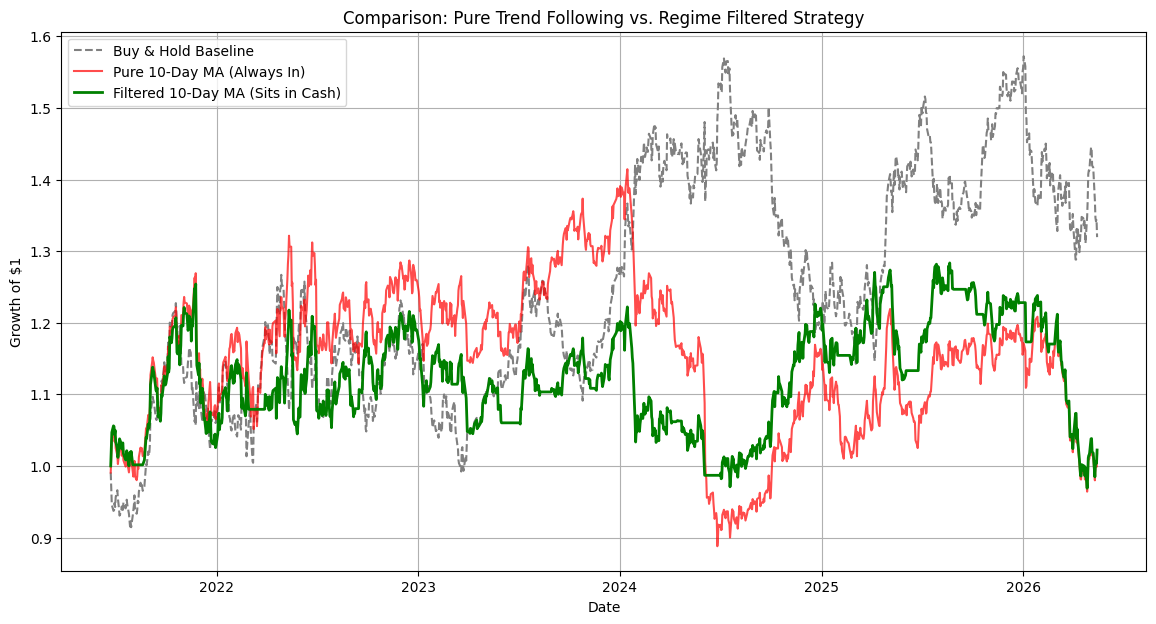

Final Baseline Return: 31.96%
Final Pure 10-Day MA Return: 1.72%
Final Filtered Strategy Return: 2.22%


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Baseline
df_comp = data.copy().sort_index()
df_comp['Market_Return'] = df_comp['Close'].pct_change()

#1: Pure 10-Day Moving Average (Always In the Market) ---
df_comp['MA_10'] = df_comp['Close'].rolling(window=10).mean()
df_comp['Strat1_Signal'] = np.where(df_comp['Close'] > df_comp['MA_10'], 1, -1)
df_comp['Strat1_Pos'] = df_comp['Strat1_Signal'].shift(1)
df_comp['Strat1_Return'] = df_comp['Market_Return'] * df_comp['Strat1_Pos']

# 2: 10-Day MA WITH ADX Regime Filter (Sits in Cash) ---
# Calculate True Range and Directional Movement
df_comp['H-L'] = df_comp['High'] - df_comp['Low']
df_comp['H-PC'] = (df_comp['High'] - df_comp['Close'].shift(1)).abs()
df_comp['L-PC'] = (df_comp['Low'] - df_comp['Close'].shift(1)).abs()
df_comp['TR'] = df_comp[['H-L', 'H-PC', 'L-PC']].max(axis=1)

df_comp['UpMove'] = df_comp['High'] - df_comp['High'].shift(1)
df_comp['DownMove'] = df_comp['Low'].shift(1) - df_comp['Low']
df_comp['+DM'] = np.where((df_comp['UpMove'] > df_comp['DownMove']) & (df_comp['UpMove'] > 0), df_comp['UpMove'], 0)
df_comp['-DM'] = np.where((df_comp['DownMove'] > df_comp['UpMove']) & (df_comp['DownMove'] > 0), df_comp['DownMove'], 0)

# Smooth over 14 days to compute ADX
adx_w = 14
df_comp['TR_s'] = df_comp['TR'].rolling(window=adx_w).sum()
df_comp['+DM_s'] = df_comp['+DM'].rolling(window=adx_w).sum()
df_comp['-DM_s'] = df_comp['-DM'].rolling(window=adx_w).sum()

df_comp['+DI'] = 100 * (df_comp['+DM_s'] / df_comp['TR_s'])
df_comp['-DI'] = 100 * (df_comp['-DM_s'] / df_comp['TR_s'])
df_comp['DX'] = 100 * (df_comp['+DI'] - df_comp['-DI']).abs() / (df_comp['+DI'] + df_comp['-DI'])
df_comp['ADX'] = df_comp['DX'].rolling(window=adx_w).mean()

# Apply the filter: If ADX <= 22, force position to 0 (Cash)
df_comp['Strat2_Signal'] = np.where(df_comp['ADX'] > 22, df_comp['Strat1_Signal'], 0)
df_comp['Strat2_Pos'] = df_comp['Strat2_Signal'].shift(1)
df_comp['Strat2_Return'] = df_comp['Market_Return'] * df_comp['Strat2_Pos']

# --- 2. Calculate Cumulative Equity Performance ---
df_comp = df_comp.dropna()
df_comp['Baseline_Cum'] = (1 + df_comp['Market_Return'].fillna(0)).cumprod()
df_comp['Unfiltered_Cum'] = (1 + df_comp['Strat1_Return'].fillna(0)).cumprod()
df_comp['Filtered_Cum'] = (1 + df_comp['Strat2_Return'].fillna(0)).cumprod()

#  Plot Comparison Side by Side
plt.figure(figsize=(14, 7))
plt.plot(df_comp['Baseline_Cum'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_comp['Unfiltered_Cum'], label='Pure 10-Day MA (Always In)', color='red', alpha=0.7)
plt.plot(df_comp['Filtered_Cum'], label='Filtered 10-Day MA (Sits in Cash)', color='green', linewidth=2)

plt.title('Comparison: Pure Trend Following vs. Regime Filtered Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Baseline Return: {(df_comp['Baseline_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Pure 10-Day MA Return: {(df_comp['Unfiltered_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Filtered Strategy Return: {(df_comp['Filtered_Cum'].iloc[-1] - 1) * 100:.2f}%")

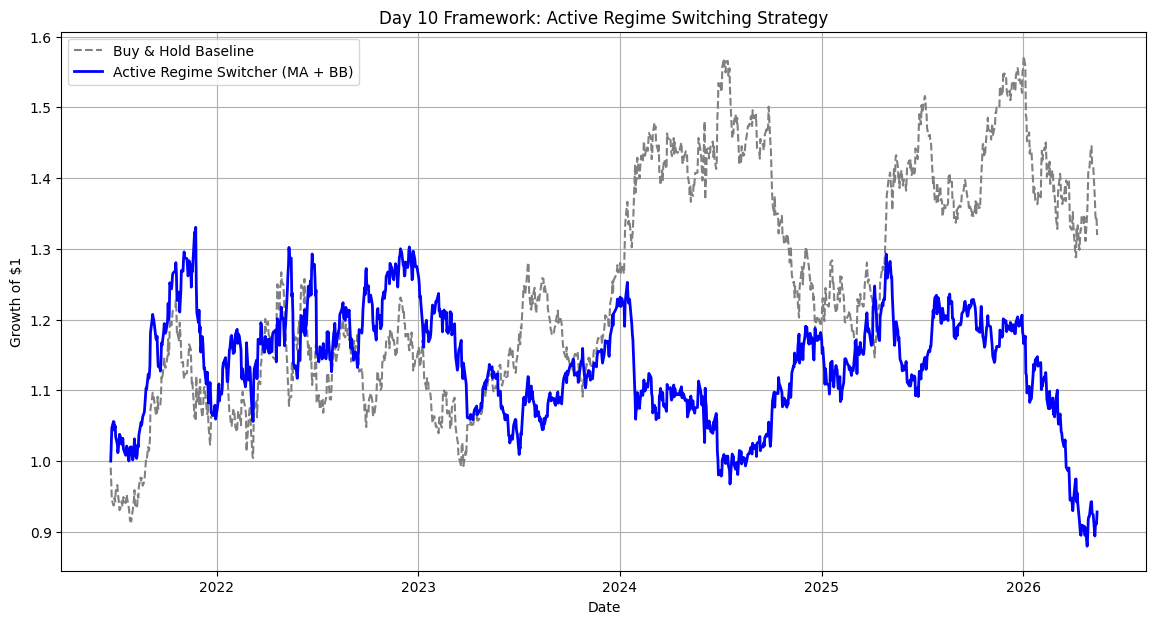

Final Baseline Return: 31.96%
Final Active Switcher Return: -7.19%


In [20]:
#Create a clean copy of your data named df_custom.Compute a 10-day moving average of the 'Close' price and name the column MA_10.
#Create the trend signal column named Trend_Signal: If 'Close' > MA_10, the signal is 1, otherwise -1. Use np.where().
#Compute a 20-day moving average (MA_20) and a 20-day rolling standard deviation (STD_20) of the 'Close' price using 
#.rolling(window=20).mean() and .std().Create the Bollinger upper and lower bands:
#Upper_B = $MA_{20} + (2 \times STD_{20})$Lower_B = $MA_{20} - (2 \times STD_{20})$

df_active = data.copy().sort_index()
df_active['Market_Return'] = df['Close'].pct_change()

df_active['MA_10'] = df_active['Close'].rolling(window=10).mean()
df_active['Trend_Signal'] = np.where(df_active['Close'] >df_active['MA_10'], 1, -1)

df_active['MA_20'] = df_active['Close'].rolling(window=20).mean()
df_active['STD_20'] = df_active['Close'].rolling(window=20).std()
df_active['Upper_B'] = df_active['MA_20'] + (df_active['STD_20']*2 )
df_active['Lower_B'] = df_active['MA_20'] - (df_active['STD_20']*2 )

df_active['MR_Signal'] = 0
df_active.loc[df_active['Close'] < df_active['Lower_B'], 'MR_Signal'] = 1   # Buy bottom
df_active.loc[df_active['Close'] > df_active['Upper_B'], 'MR_Signal'] = -1  # Sell top
df_active['MR_Signal'] = df_active['MR_Signal'].replace(0, np.nan).ffill().fillna(0)

# 14-Day ADX
df_active['H-L'] = df_active['High'] - df_active['Low']
df_active['H-PC'] = (df_active['High'] - df_active['Close'].shift(1)).abs()
df_active['L-PC'] = (df_active['Low'] - df_active['Close'].shift(1)).abs()
df_active['TR'] = df_active[['H-L', 'H-PC', 'L-PC']].max(axis=1)

df_active['UpMove'] = df_active['High'] - df_active['High'].shift(1)
df_active['DownMove'] = df_active['Low'].shift(1) - df_active['Low']
df_active['+DM'] = np.where((df_active['UpMove'] > df_active['DownMove']) & (df_active['UpMove'] > 0), df_active['UpMove'], 0)
df_active['-DM'] = np.where((df_active['DownMove'] > df_active['UpMove']) & (df_active['DownMove'] > 0), df_active['DownMove'], 0)

adx_w = 14
df_active['TR_s'] = df_active['TR'].rolling(window=adx_w).sum()
df_active['+DM_s'] = df_active['+DM'].rolling(window=adx_w).sum()
df_active['-DM_s'] = df_active['-DM'].rolling(window=adx_w).sum()

df_active['+DI'] = 100 * (df_active['+DM_s'] / df_active['TR_s'])
df_active['-DI'] = 100 * (df_active['-DM_s'] / df_active['TR_s'])
df_active['DX'] = 100 * (df_active['+DI'] - df_active['-DI']).abs() / (df_active['+DI'] + df_active['-DI'])
df_active['ADX'] = df_active['DX'].rolling(window=adx_w).mean()

# If ADX > 22 -> Use Trend Signal. If ADX <= 22 -> Use Mean Reversion Signal
df_active['Master_Signal'] = np.where(df_active['ADX'] > 22, df_active['Trend_Signal'], df_active['MR_Signal'])
df_active['Master_Pos'] = df_active['Master_Signal'].shift(1)
df_active['Active_Strat_Return'] = df_active['Market_Return'] * df_active['Master_Pos']

# Cumulative Performance
df_active = df_active.dropna()
df_active['Baseline_Cum'] = (1 + df_active['Market_Return'].fillna(0)).cumprod()
df_active['Active_Switcher_Cum'] = (1 + df_active['Active_Strat_Return'].fillna(0)).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_active['Baseline_Cum'], label='Buy & Hold Baseline', color='gray', linestyle='--')
plt.plot(df_active['Active_Switcher_Cum'], label='Active Regime Switcher (MA + BB)', color='blue', linewidth=2)

plt.title('Day 10 Framework: Active Regime Switching Strategy')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Baseline Return: {(df_active['Baseline_Cum'].iloc[-1] - 1) * 100:.2f}%")
print(f"Final Active Switcher Return: {(df_active['Active_Switcher_Cum'].iloc[-1] - 1) * 100:.2f}%")